In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
RANDOMSTATE = 42
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from scipy.stats import norm
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, classification_report
from scipy.stats import uniform
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings


## EDA

### Load Data

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

### Basic Info

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Target Analysis

<Axes: xlabel='Churn', ylabel='count'>

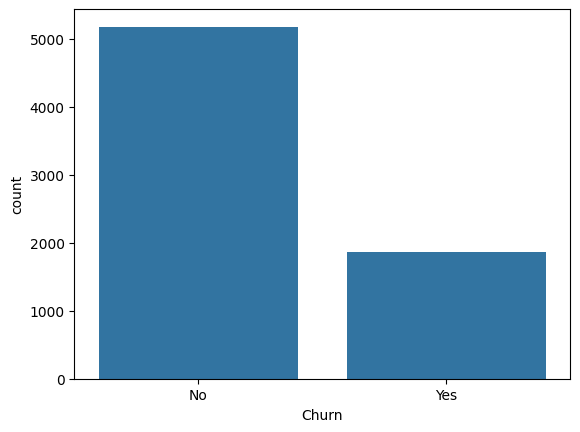

In [7]:
sns.countplot(data = df, x = 'Churn')

Easy to notice data is Imbalanced <br>
I will handle it After Scaling and before train 

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts() / len(df)

Churn
No     0.73463
Yes    0.26537
Name: count, dtype: float64

### Feature Analysis

In [10]:
# Check the number of unique entries per column
df_columns = list(df.columns)
for i, feature in enumerate(df_columns):
    print(f'{feature} unique values: {df[feature].nunique()}')
    print('----------------')

customerID unique values: 7043
----------------
gender unique values: 2
----------------
SeniorCitizen unique values: 2
----------------
Partner unique values: 2
----------------
Dependents unique values: 2
----------------
tenure unique values: 73
----------------
PhoneService unique values: 2
----------------
MultipleLines unique values: 3
----------------
InternetService unique values: 3
----------------
OnlineSecurity unique values: 3
----------------
OnlineBackup unique values: 3
----------------
DeviceProtection unique values: 3
----------------
TechSupport unique values: 3
----------------
StreamingTV unique values: 3
----------------
StreamingMovies unique values: 3
----------------
Contract unique values: 3
----------------
PaperlessBilling unique values: 2
----------------
PaymentMethod unique values: 4
----------------
MonthlyCharges unique values: 1585
----------------
TotalCharges unique values: 6531
----------------
Churn unique values: 2
----------------


make sure Nan not a label in features has more than 2 labels 

In [11]:
cont_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_list = df_columns.copy()
for i in range (len(cont_col)):
    cat_list.remove(cont_col[i])
cat_list.remove('Churn')
cat_list.remove('customerID')
print(len(cat_list))

16


In [12]:
for feature in cat_list:
    print(f'{feature} unique values: {df[feature].unique()}')

gender unique values: ['Female' 'Male']
SeniorCitizen unique values: [0 1]
Partner unique values: ['Yes' 'No']
Dependents unique values: ['No' 'Yes']
PhoneService unique values: ['No' 'Yes']
MultipleLines unique values: ['No phone service' 'No' 'Yes']
InternetService unique values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity unique values: ['No' 'Yes' 'No internet service']
OnlineBackup unique values: ['Yes' 'No' 'No internet service']
DeviceProtection unique values: ['No' 'Yes' 'No internet service']
TechSupport unique values: ['No' 'Yes' 'No internet service']
StreamingTV unique values: ['No' 'Yes' 'No internet service']
StreamingMovies unique values: ['No' 'Yes' 'No internet service']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling unique values: ['Yes' 'No']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


convert numeric feature from object type to float

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

check null values 

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
print(f'number of missing values= {df["TotalCharges"].isnull().sum()}')

number of missing values= 11


check is Nan values is new brand customers

In [16]:
for feature in cont_col:
    print(f'{feature} has {(df[feature] == 0).sum()} zeros ')

tenure has 11 zeros 
MonthlyCharges has 0 zeros 
TotalCharges has 0 zeros 


In [17]:
df[df['tenure']== 0][['tenure', 'TotalCharges', 'MonthlyCharges']]

,tenure,TotalCharges,MonthlyCharges
488,0,NaN,52.55
753,0,NaN,20.25
936,0,NaN,80.85
1082,0,NaN,25.75
1340,0,NaN,56.05
3331,0,NaN,19.85
3826,0,NaN,25.35
4380,0,NaN,20.00
5218,0,NaN,19.70
6670,0,NaN,73.35


this indicate that they are brand new customers<br>
After indicate that they are valid data, i will impute NaN with 0 <br>

#### Columns distribution

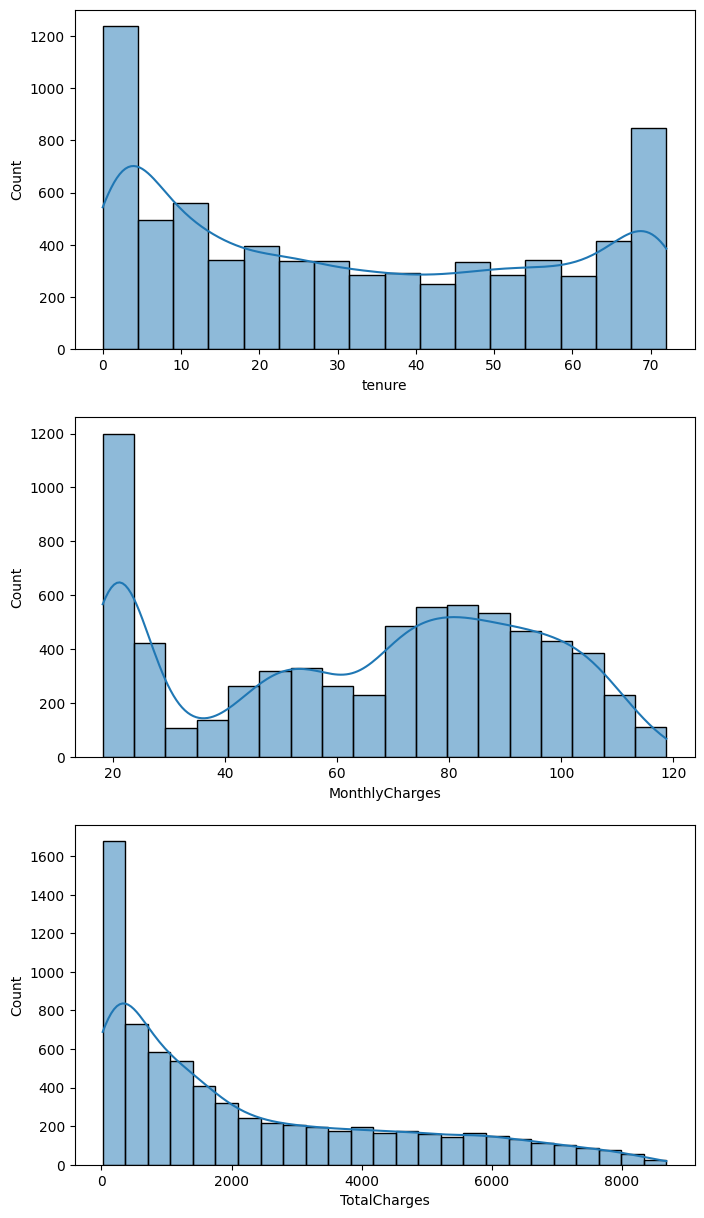

In [18]:
fig, axes = plt.subplots(3, 1, figsize =(8, 15))
for i, axis in enumerate(axes):
    sns.histplot(data = df, x = cont_col[i], ax= axis, kde=True)

#### Visualizing Categorical Distributions with Countplots

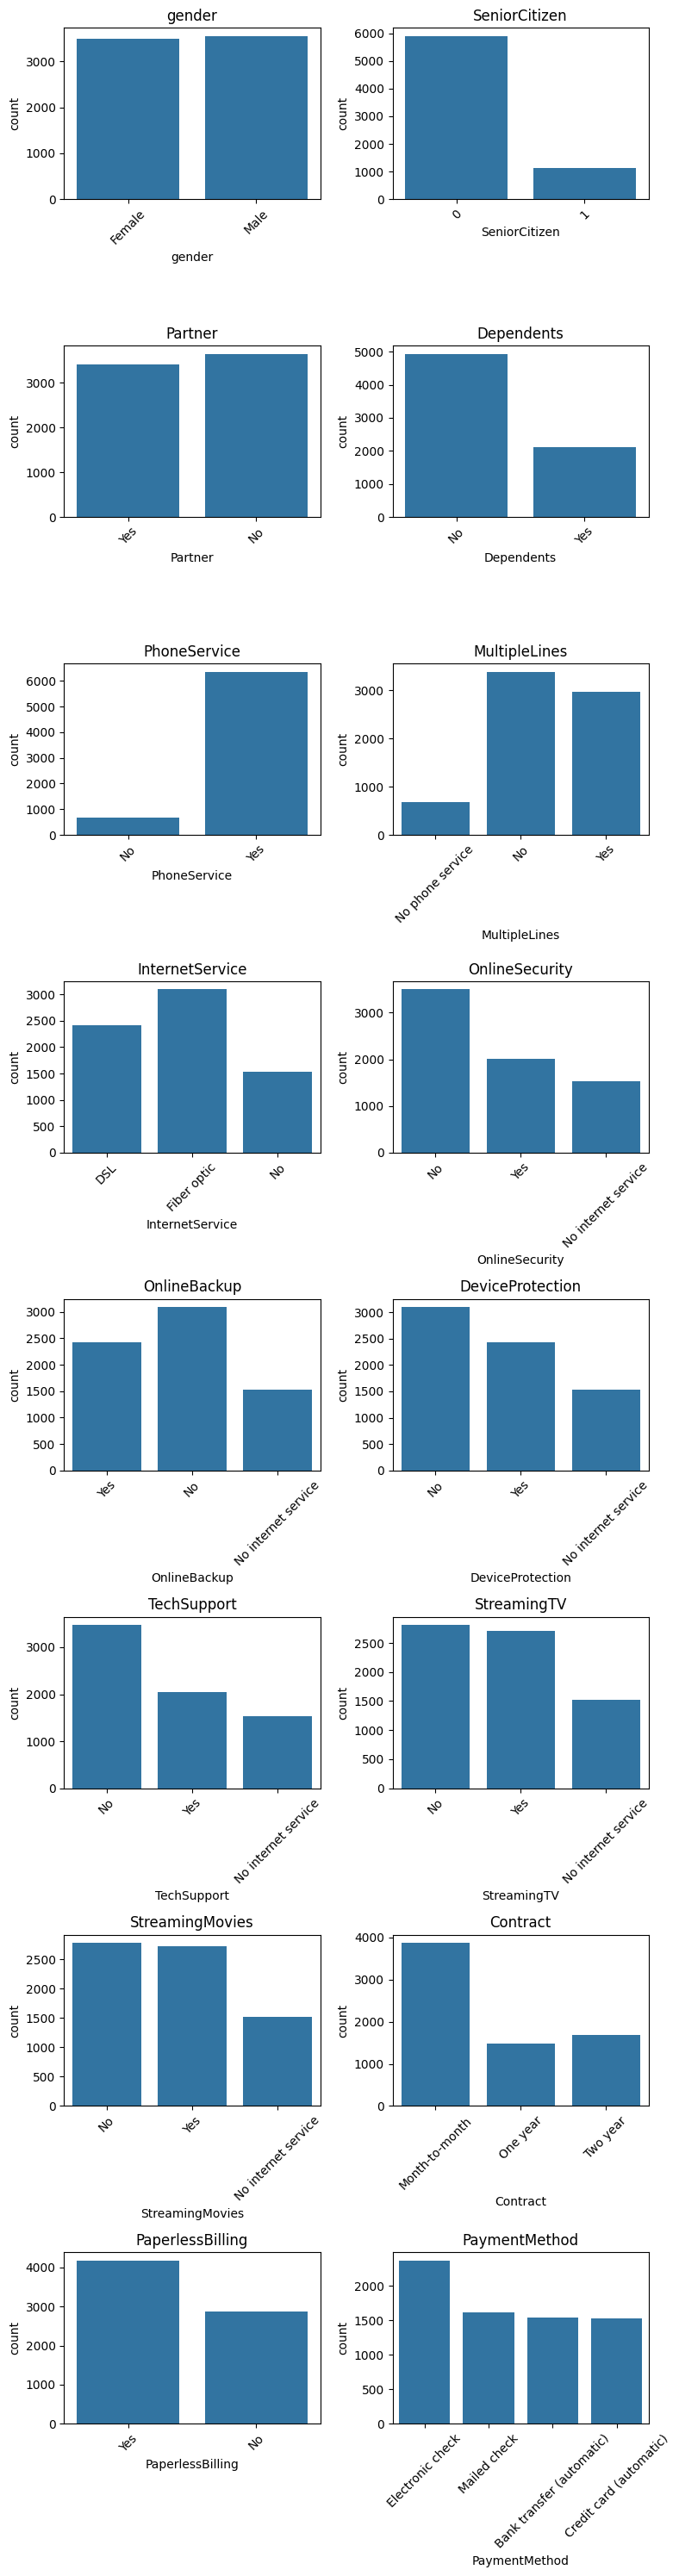

In [19]:
fig, axes = plt.subplots(8, 2, figsize = (8, 30))
axes = axes.flatten()
for i, feature in enumerate(cat_list):
    if i == 18:
        continue
    sns.countplot(data = df, x = feature, ax = axes[i])
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout() 
plt.show()

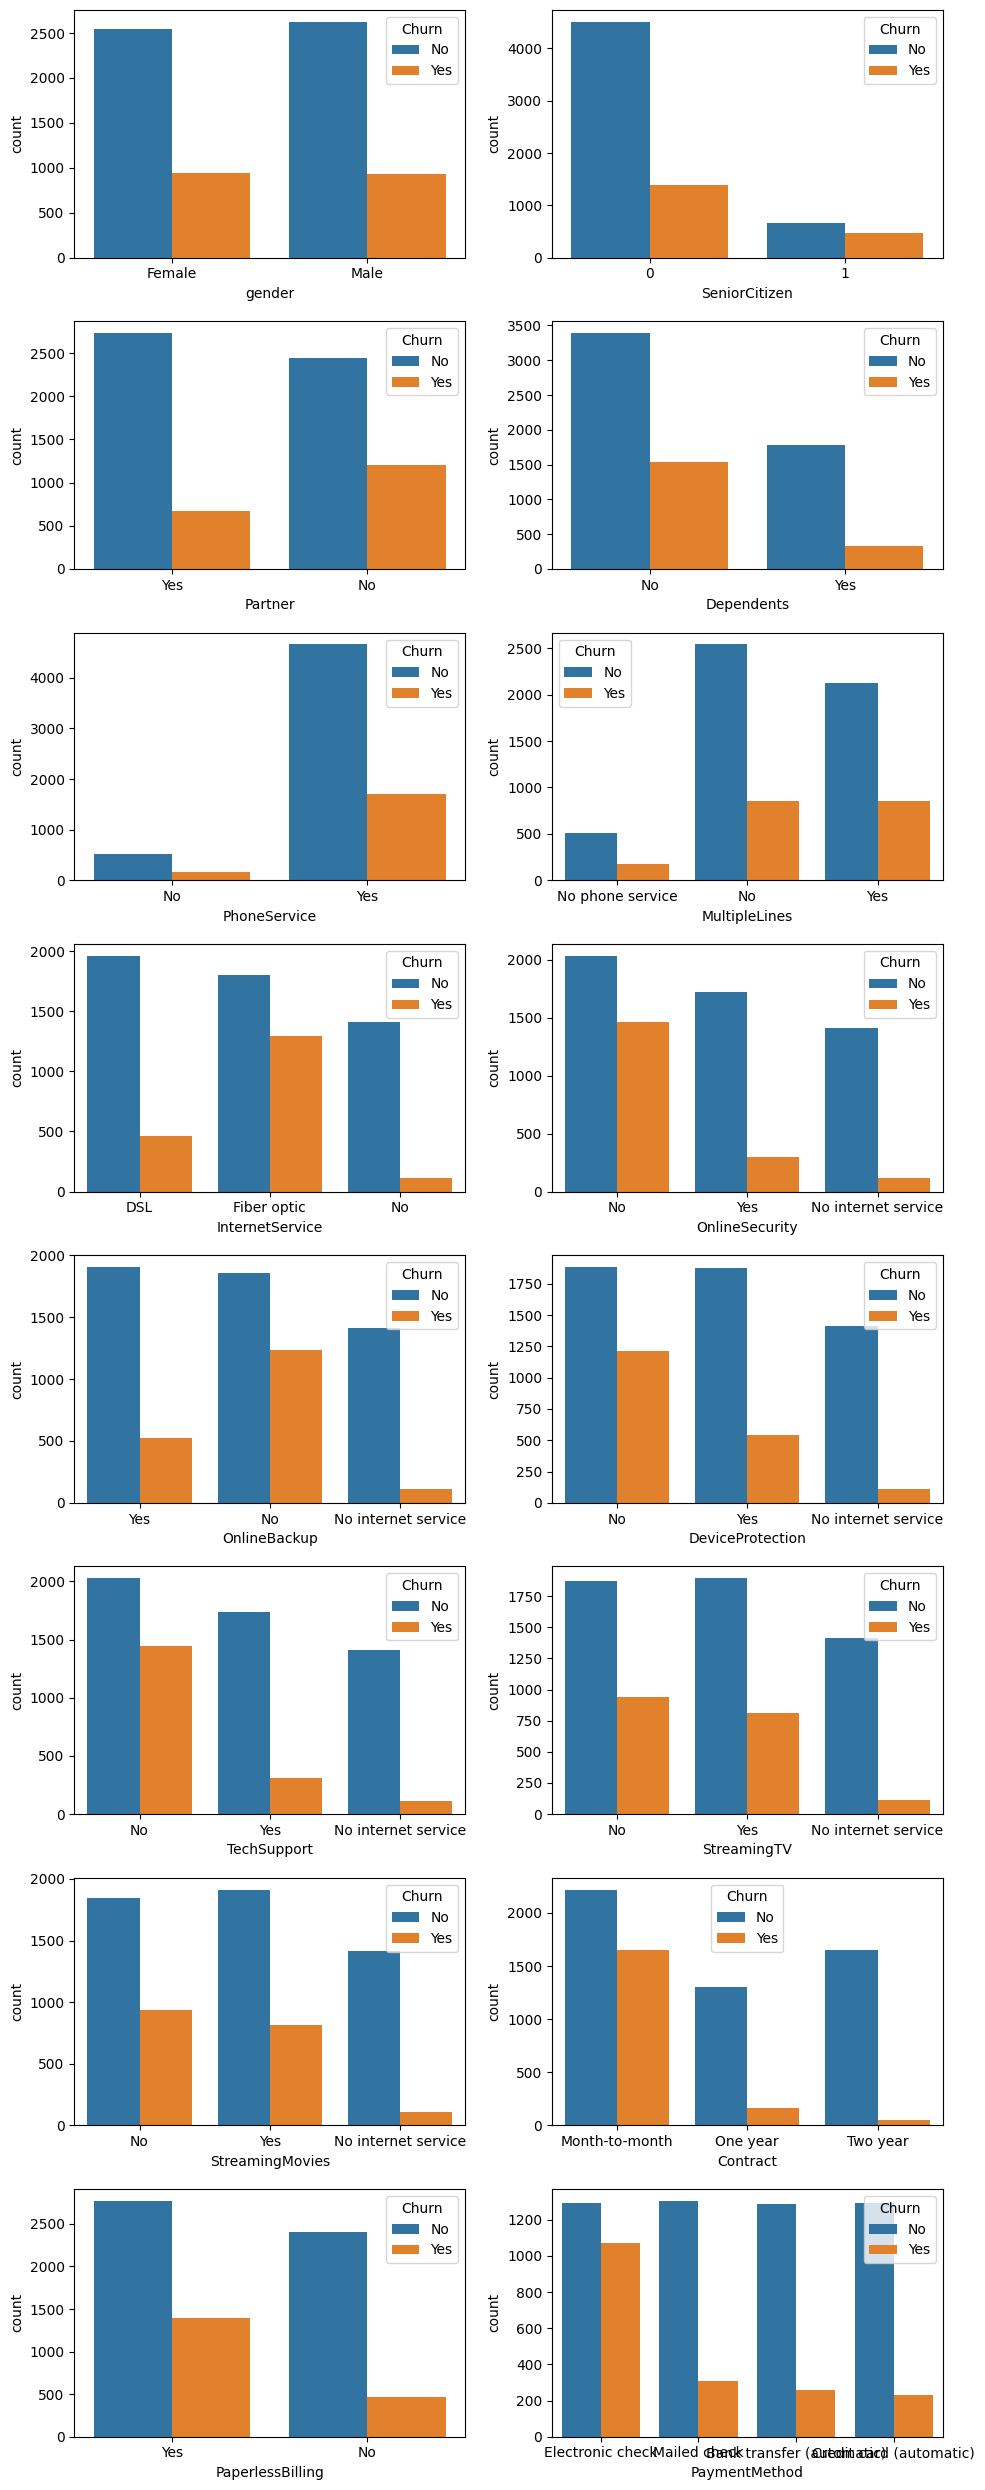

In [20]:
fig, axes = plt.subplots(8, 2, figsize = (10, 25))
axes = axes.flatten()
for i, feature in enumerate(cat_list):
    if i == 18:
        continue
    sns.countplot(data = df, x = feature, ax = axes[i], hue = 'Churn')

plt.tight_layout() 
plt.show()

#### Distribution of target variable across each continuous feature - check for separation and outliers

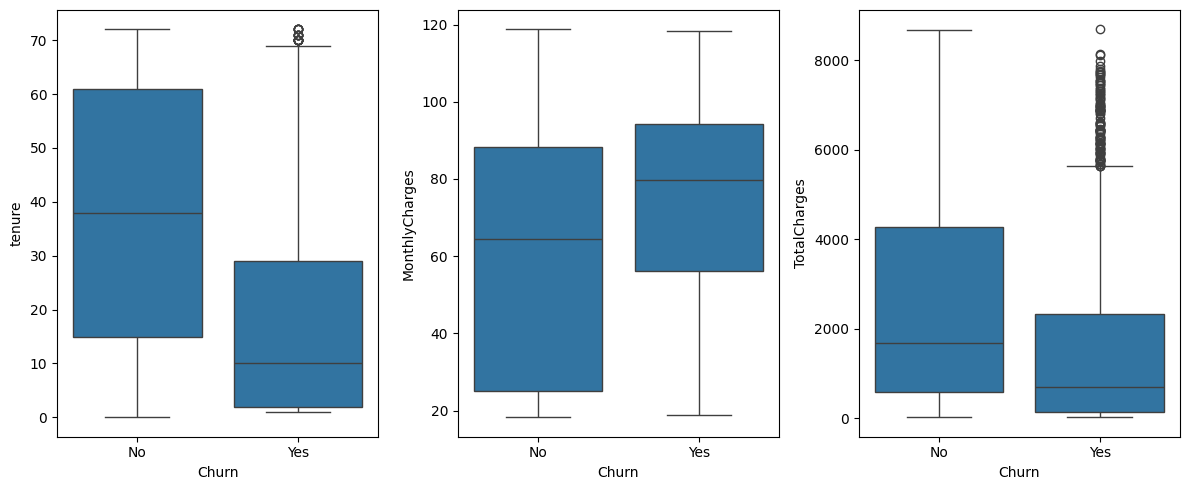

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12,5))
for i, feature in enumerate(cont_col):
    sns.boxplot(data = df, x = 'Churn', y = feature, ax = axes[i])
plt.tight_layout()
plt.show()

#### Separation
- Tenure(The best separation) 
&nbsp;&nbsp;&nbsp;&nbsp;**not churn**: median(38), IQR(18-60)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**Churn**: median(10), IQR(3-28)<br>

- **MonthlyCharges** (the weakest Separation)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(65), IQR(25-85)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(80), IQR(58-90)<br>

- **TotalCharges** (second best)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(1800), IQR(800-4200)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(1000), IQR(500-2400)<br>

<br>
model can to a certain degree easily distinguish between the two classes using Tenure.

##### Outliers
Tenure - no significant outliers in either classes<br>
MonthlyCharges - no significant outliers in either classes<br>
MonthlyCharges - no significant outliers in either classes<br>


#### Rename Churn labels

In [22]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

#### Correlation Matrix

<Axes: >

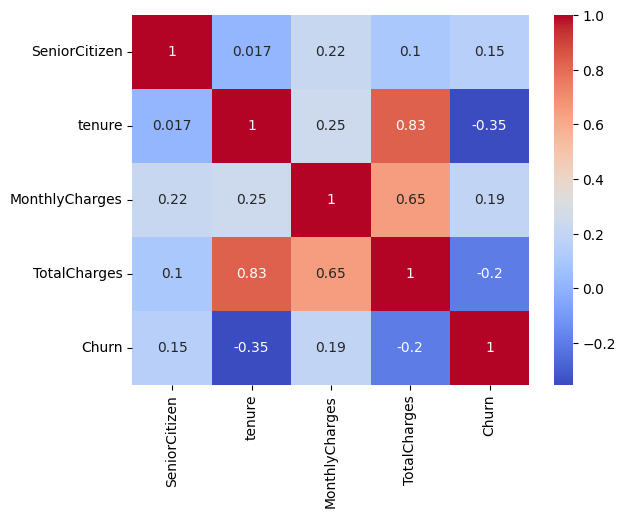

In [23]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

## Data Cleaning and Preprocessing

### Drop unique Identifier (unpredictive)

In [24]:
df.drop('customerID', axis = 1, inplace=True)

### Handle Duplicates

In [25]:
df.duplicated().sum()

22

In [26]:
df.drop_duplicates(inplace=True)

### Handle missing values

In [27]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [28]:
df['TotalCharges'].isnull().sum()

0

### split data 

In [29]:
df_train, df_temp, y_train, y_temp = train_test_split(df.drop('Churn', axis = 1), df['Churn'], test_size= 0.2, random_state=42)
df_val, df_test, y_val, y_test = train_test_split(df_temp, y_temp, test_size=0.5, random_state=42)

In [30]:
def log_transform(df):
    df['MonthlyCharges'] = np.log(df['MonthlyCharges']+ 1)
    df['TotalCharges'] = np.log(df['TotalCharges'] + 1)
    df['tenure'] = np.log(df['tenure']+ 1)
    return df

In [31]:
df_train = log_transform(df_train)
df_val = log_transform(df_val)
df_test = log_transform(df_test)

### Encoding

In [32]:
cat_nom = ['gender', 'Dependents', 'PaperlessBilling', 'PaymentMethod', 'Partner', 'PhoneService']
cat_ord = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract' ]

In [33]:
ordinal_categories = [
    ['No phone service', 'No', 'Yes',],
    ['No', 'DSL', 'Fiber optic'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['Month-to-month', 'One year', 'Two year'],
]

In [34]:
col_transfer = ColumnTransformer(
    transformers=[
        ('nom', OneHotEncoder(drop= 'first', sparse_output=False), cat_nom),
        ('ord', OrdinalEncoder(categories = ordinal_categories), cat_ord)
    ],
    verbose_feature_names_out= False,
    remainder= 'passthrough',
    
)
col_transfer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('nom',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['gender', 'Dependents', 'PaperlessBilling',
                                  'PaymentMethod', 'Partner', 'PhoneService']),
                                ('ord',
                                 OrdinalEncoder(categories=[['No phone service',
                                                             'No', 'Yes'],
                                                            ['No', 'DSL',
                                                             'Fiber optic'],
                                                            ['No internet '
                                                             'service',
                                                             'No', 'Yes'],
                                                            ['No internet '
                                                             'service',
                                                             'No', '...
                                                            ['No internet '
                                                             'service',
                                                             'No', 'Yes'],
                                                            ['No internet '
                                                             'service',
                                                             'No', 'Yes'],
                                                            ['No internet '
                                                             'service',
                                                             'No', 'Yes'],
                                                            ['No internet '
                                                             'service',
                                                             'No', 'Yes'],
                                                            ['Month-to-month',
                                                             'One year',
                                                             'Two year']]),
                                 ['MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies',
                                  'Contract'])],
                  verbose_feature_names_out=False)

In [35]:
col_transfer.fit(df_train)
df_train = col_transfer.transform(df_train)
df_val = col_transfer.transform(df_val)
df_test = col_transfer.transform(df_test)

### Feature Engineering 

<Axes: >

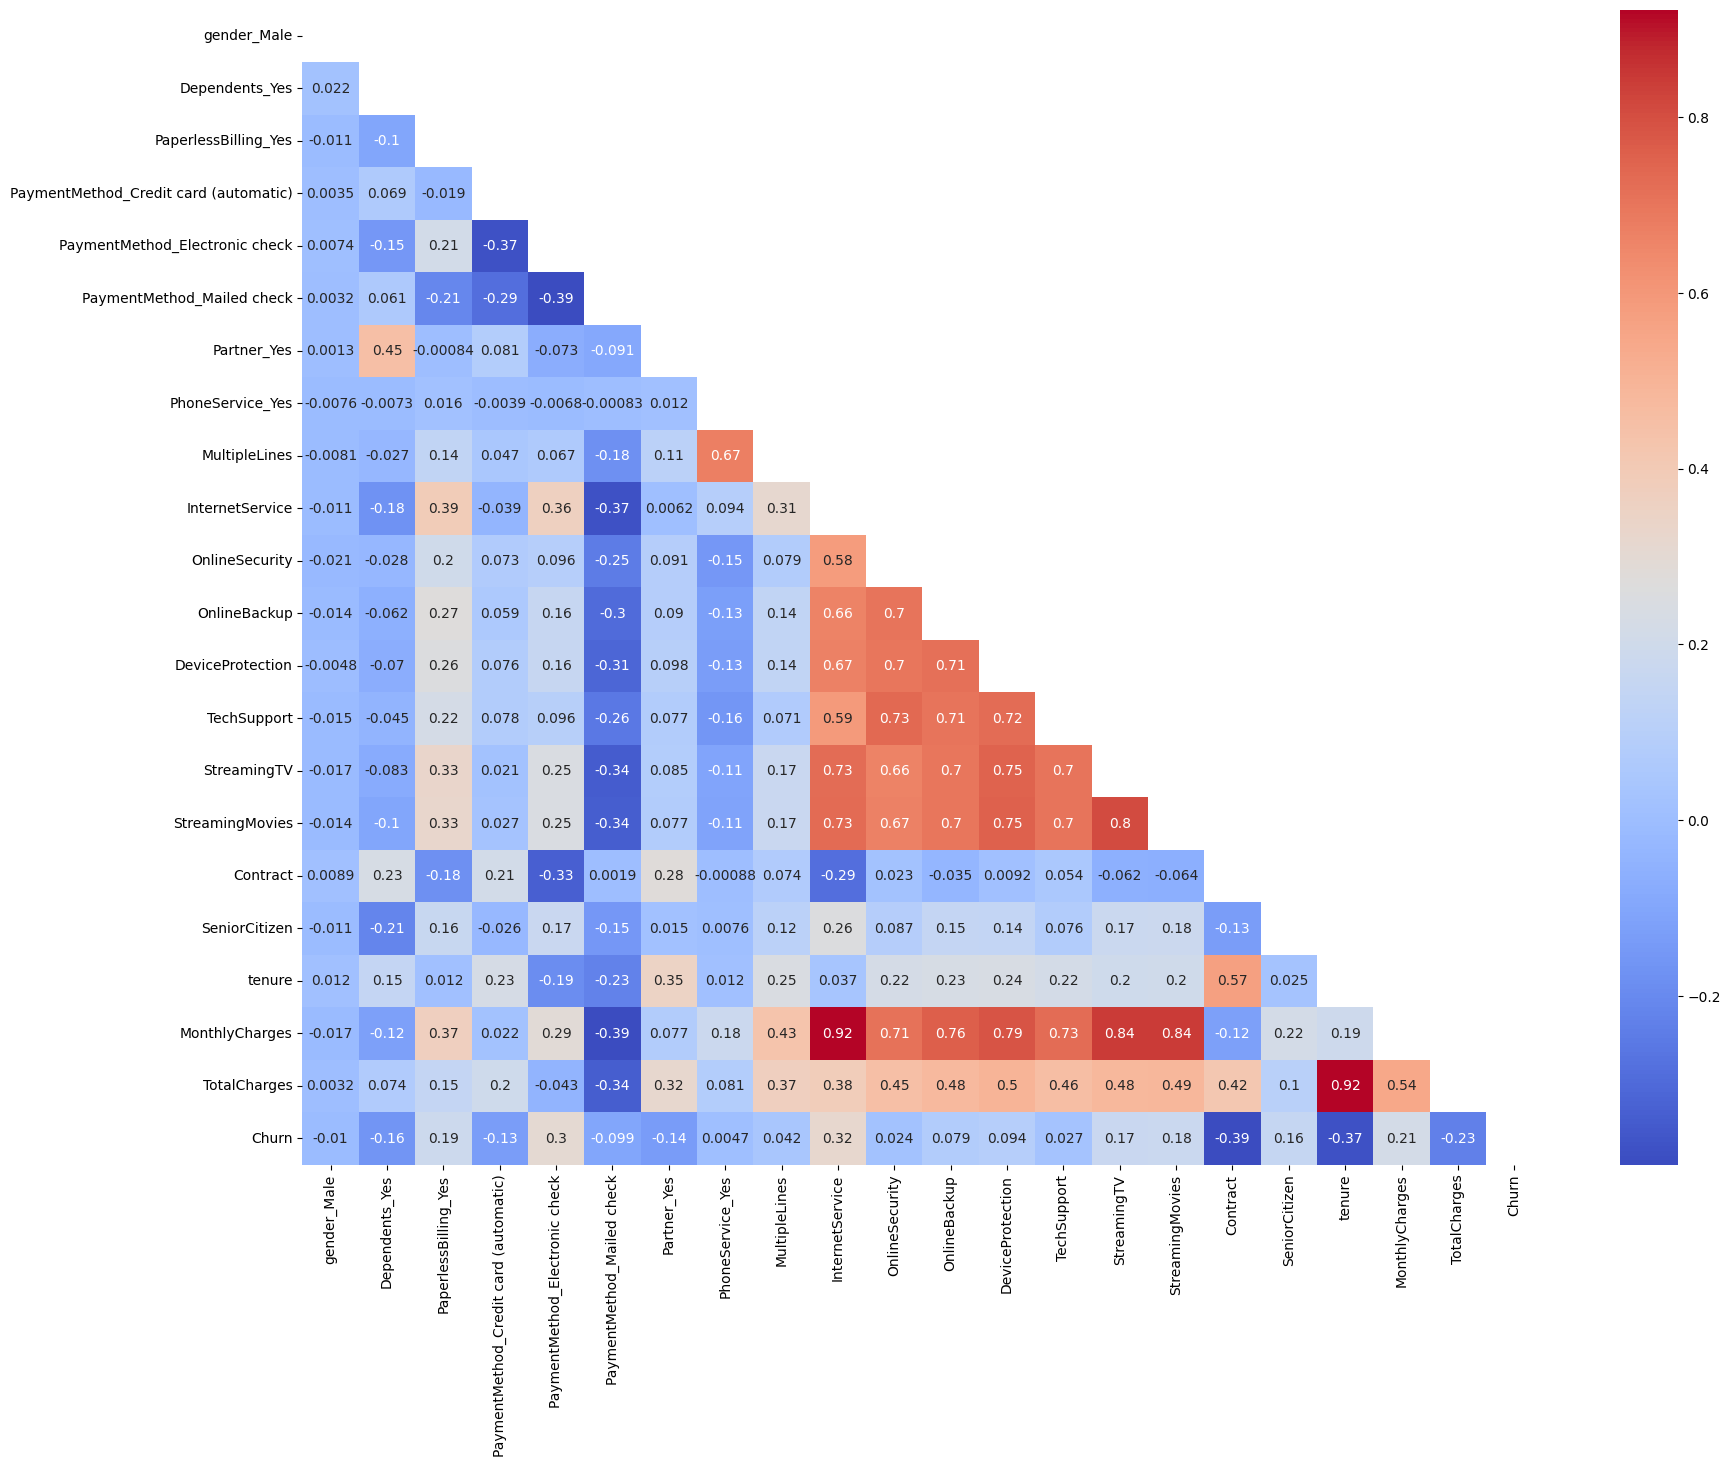

In [36]:
plt.figure(figsize=(20, 15))
corr = pd.concat([df_train, y_train],axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask = mask, annot=True , annot_kws = {'size':10}, cmap = 'coolwarm')

Internet-Related Features: I will replace the "No internet service" label into "No". Since InternetService has a high correlation with the target, I just removing the redundant sub-labels to simplify the model.

Phone-Related Features: I will not clean the redundant "No phone service" labels. Because PhoneService and its related features show low correlation with the target, these features will be dropped entirely.

In [37]:
def remove_redund(df):
    cat_tofix= ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',]
    df = df.copy()
    for feature in cat_tofix:
        df[feature]  = df[feature].replace({1: 0, 2:1})
    return df

In [38]:
df_train = remove_redund(df_train)
df_val = remove_redund(df_val)
df_test = remove_redund(df_test)

In [39]:
def feature_eng(df):
    df = df.copy()
    df['average_charges'] = df['TotalCharges'] / (df['tenure'] + 1)
    df['monthly_to_total'] = df['MonthlyCharges'] / (df['TotalCharges']+ 1)
    df['charges_deviation'] = df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']
    df['Family'] = df['Partner_Yes'] + df['Dependents_Yes']
    # drop columns has < 0.1 corr with target
    df = df.drop(['gender_Male', 'PhoneService_Yes', 'MultipleLines', 'OnlineBackup', 'DeviceProtection','StreamingTV', 'StreamingMovies', 'Dependents_Yes', 'Partner_Yes', 'TotalCharges', 'MonthlyCharges', 'tenure'], axis = 1)
    return df 

In [40]:
df_train = feature_eng(df_train)
df_val = feature_eng(df_val)
df_test = feature_eng(df_test)

<Axes: >

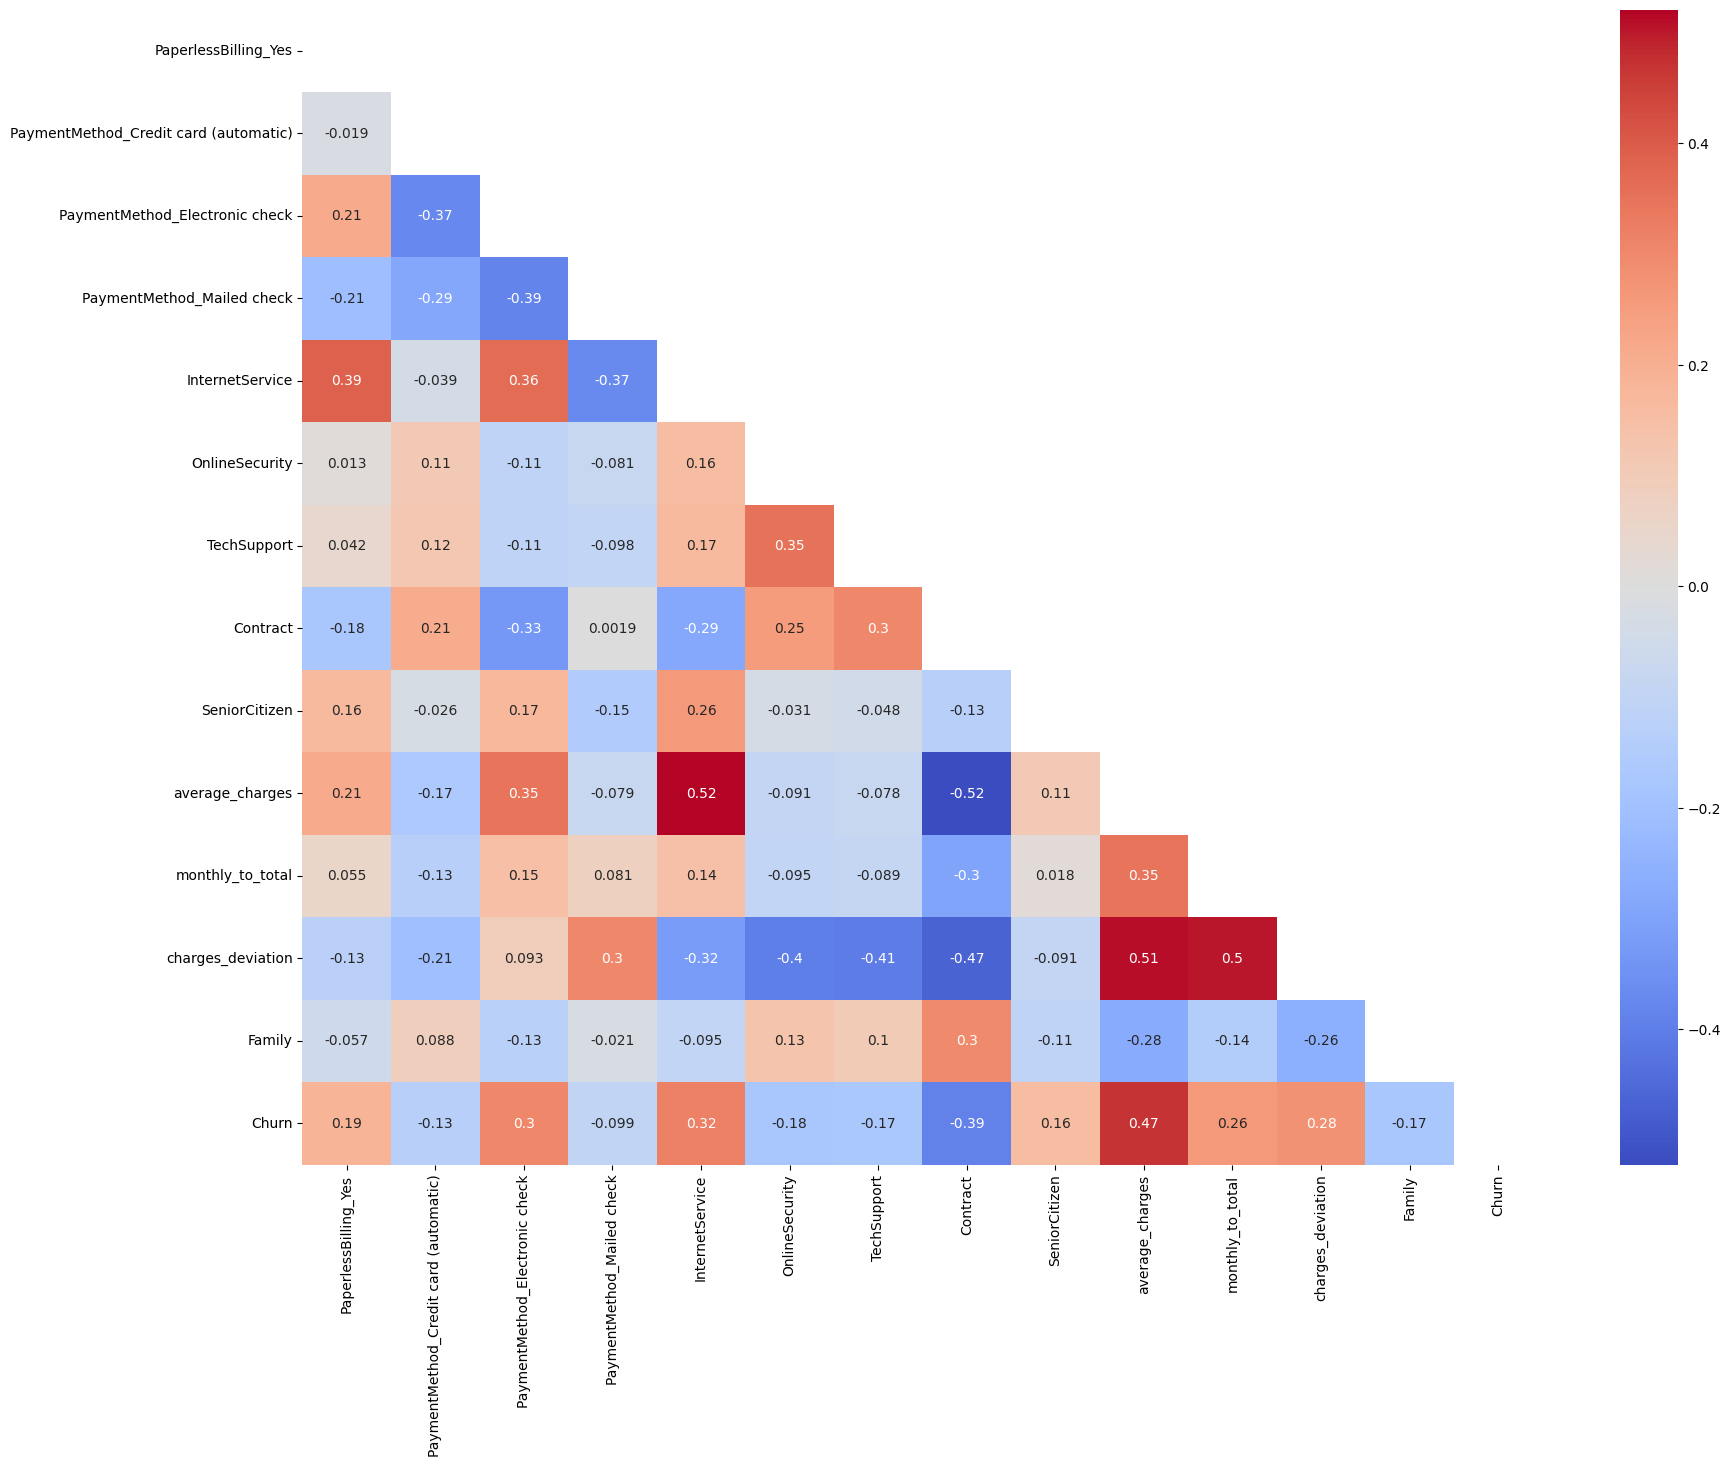

In [41]:
plt.figure(figsize=(20, 15))
corr = pd.concat([df_train, y_train],axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask = mask, annot=True , annot_kws = {'size':10}, cmap = 'coolwarm')

### Scaling 

In [42]:
scale_cols = ['average_charges', 'monthly_to_total', 'average_charges']
std_scaler = StandardScaler()
df_train_scaled, df_val_scaled, df_test_scaled = df_train.copy(), df_val.copy(), df_test.copy()
std_scaler.fit(df_train[scale_cols])
df_train_scaled[scale_cols] = std_scaler.transform(df_train[scale_cols])
df_val_scaled[scale_cols] = std_scaler.transform(df_val[scale_cols])
df_test_scaled[scale_cols] = std_scaler.transform(df_test[scale_cols])

#### Oversampling

In [43]:
# warnings.filterwarnings("ignore", category=FutureWarning)
# smote = SMOTE(random_state=42)
# df_train_scaled, y_train = smote.fit_resample(df_train_scaled, y_train)

## Training & Evaluation

### Linear models

#### SGDClassifier

In [44]:
sgdc = SGDClassifier(loss= 'log_loss',penalty='l2', random_state=42, class_weight= 'balanced')
sgdc.fit(df_train_scaled, y_train)
train_pred =sgdc.predict_proba(df_train_scaled)[:, 1]
train_pred = train_pred > 0.5
test_pred =sgdc.predict_proba(df_test_scaled)[:, 1]
test_pred = test_pred > 0.5
val_pred =sgdc.predict_proba(df_val_scaled)[:, 1]
val_pred = val_pred > 0.5
print(f'Train Score: {accuracy_score(train_pred, y_train)}')
print(f'Val Score: {accuracy_score(val_pred, y_val)}')
print(f'Test Score: {accuracy_score(test_pred, y_test)}')
print(f'Train f1 Score: {f1_score(train_pred, y_train)}')
print(f'Val f1 Score: {f1_score(val_pred, y_val)}')
print(f'Test f1 Score: {f1_score(test_pred, y_test)}')
print(f'Train AP-Score: {average_precision_score(train_pred, y_train)}')
print(f'Val AP-Score: {average_precision_score(val_pred,y_val)}')
print(f'Test AP-Score: {average_precision_score(test_pred, y_test)}')

Train Score: 0.7946937321937322
Val Score: 0.782051282051282
Test Score: 0.7894736842105263
Train f1 Score: 0.614510197258442
Val f1 Score: 0.5984251968503937
Test f1 Score: 0.6021505376344086
Train AP-Score: 0.47859955977228824
Val AP-Score: 0.48982918617064963
Test AP-Score: 0.48312427259795676


In [45]:
test_pred =sgdc.predict_proba(df_test_scaled)[:, 1]
test_pred = test_pred > 0.5
print(f'Test Accuracy: {accuracy_score(test_pred, y_test):.3f}')

Test Accuracy: 0.789


#### LogisticRegression 

In [ ]:
log_reg = LogisticRegression(penalty='l2', C= 300, max_iter=1000, class_weight= 'balanced')
log_reg.fit(df_train_scaled, y_train)
train_pred =log_reg.predict_proba(df_train_scaled)[:, 1]
train_pred = train_pred > 0.4
train_pred =log_reg.predict_proba(df_train_scaled)[:, 1]
train_pred = train_pred > 0.5
test_pred =log_reg.predict_proba(df_test_scaled)[:, 1]
test_pred = test_pred > 0.5
val_pred =log_reg.predict_proba(df_val_scaled)[:, 1]
val_pred = val_pred > 0.5
print(f'Train Score: {accuracy_score(train_pred, y_train)}')
print(f'Val Score: {accuracy_score(val_pred, y_val)}')
print(f'Test Score: {accuracy_score(test_pred, y_test)}')

Train Score: 0.7583689458689459
Val Score: 0.7464387464387464
Test Score: 0.7524893314366998
Train f1 Score: 0.6364854004821859
Val f1 Score: 0.6228813559322034
Test f1 Score: 0.6167400881057269
Train AP-Score: 0.6060873843179384
Val AP-Score: 0.6270426348551349
Test AP-Score: 0.5968901847356978


In [ ]:
print(f'Train f1 Score: {f1_score(train_pred, y_train)}')
print(f'Val f1 Score: {f1_score(val_pred, y_val)}')
print(f'Test f1 Score: {f1_score(test_pred, y_test)}')

In [ ]:
print(f'Train AP-Score: {average_precision_score(train_pred, y_train)}')
print(f'Val AP-Score: {average_precision_score(val_pred, y_val)}')
print(f'Test AP-Score: {average_precision_score(test_pred, y_test)}')

#### Classification Report

In [47]:
print(classification_report(test_pred, y_test))

              precision    recall  f1-score   support

       False       0.74      0.92      0.82       425
        True       0.80      0.50      0.62       278

    accuracy                           0.75       703
   macro avg       0.77      0.71      0.72       703
weighted avg       0.76      0.75      0.74       703



### Ensemble models

#### Random Forest

##### random search

In [48]:
from scipy.stats import randint
rand_param = {
    'n_estimators': randint(80, 400),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2,5), 
    'max_features': uniform(0, 1),
    'max_samples': uniform(0, 1),          
    'class_weight': [None, 'balanced']
}

In [49]:
rand_forest = RandomForestClassifier(random_state=42)
rand_search = RandomizedSearchCV(
    rand_forest,
    rand_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    verbose = 1,
    n_iter =100,
    random_state=42
)
rand_search.fit(df_train_scaled, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7198fae45490>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7198fae45a60>,
                                        'max_samples': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7198fae44910>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7198fae44820>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7198fae44be0>},
                   random_state=42, scoring='average_precision', verbose=1)

In [50]:
best_model = rand_search.best_estimator_
print(f'n_estimator: {best_model.get_params()["n_estimators"]}')
print(f'max depth: {best_model.get_params()["max_depth"]}')
print(f'min_samples_split: {best_model.get_params()["min_samples_split"]}')

n_estimator: 373
max depth: 10
min_samples_split: 3


In [ ]:
pred_train = best_model.predict(df_train_scaled)
pred_val = best_model.predict(df_val_scaled)
pred_test = best_model.predict(df_test_scaled)
print(f'Train acc Score: {accuracy_score(pred_train, y_train)}')
print(f'Val acc Score: {accuracy_score(pred_val, y_val)}')
print(f'Test acc Score: {accuracy_score(pred_test, y_test)}')



Train acc Score: 0.8158831908831908
Val acc Score: 0.8062678062678063
Test acc Score: 0.7965860597439545
Train f1 Score: 0.6291248206599713
Val f1 Score: 0.6023391812865497
Test f1 Score: 0.5705705705705706
Train AP-Score: 0.4706170399943171
Val AP-Score: 0.45286653607436744
Test AP-Score: 0.41480752725724235


In [ ]:
print(f'Train f1 Score: {f1_score(pred_train, y_train)}')
print(f'Val f1 Score: {f1_score(pred_val, y_val)}')
print(f'Test f1 Score: {f1_score(pred_test, y_test)}')

In [ ]:
print(f'Train AP-Score: {average_precision_score(pred_train, y_train)}')
print(f'Val AP-Score: {average_precision_score(pred_val,y_val)}')
print(f'Test AP-Score: {average_precision_score(pred_test, y_test)}')

In [52]:
rand_forest = RandomForestClassifier(random_state=42, verbose = False )
grid_param = {
    'n_estimators': [300, 350, 470],
    'max_depth': [7, 8, 11],
    'min_samples_split': [2, 3, 4],
    'class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(
    rand_forest,
    grid_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    verbose = False,
)
grid_search.fit(df_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(random_state=42, verbose=False),
             n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [7, 8, 11],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 350, 470]},
             scoring='average_precision', verbose=False)

In [53]:
best_model = grid_search.best_estimator_
print(f'n_estimator: {best_model.get_params()["n_estimators"]}')
print(f'max depth: {best_model.get_params()["max_depth"]}')
print(f'min_samples_split: {best_model.get_params()["min_samples_split"]}')
print(f'class weight: {best_model.get_params()["class_weight"]}')

n_estimator: 470
max depth: 8
min_samples_split: 2
class weight: None


In [ ]:
pred_train = best_model.predict(df_train_scaled)
pred_val = best_model.predict(df_val_scaled)
pred_test = best_model.predict(df_test_scaled)
print(f'Train acc Score: {accuracy_score(pred_train, y_train)}')
print(f'Val acc Score: {accuracy_score(pred_val, y_val)}')
print(f'Test acc Score: {accuracy_score(pred_test, y_test)}')

Train acc Score: 0.8354700854700855
Val acc Score: 0.8048433048433048
Test acc Score: 0.7994310099573257
Train f1 Score: 0.6494688922610015
Val f1 Score: 0.5678233438485805
Test f1 Score: 0.555205047318612
Train AP-Score: 0.47944272195475085
Val AP-Score: 0.39905189373274474
Test AP-Score: 0.387447918242991


In [ ]:
print(f'Train f1 Score: {f1_score(pred_train, y_train)}')
print(f'Val f1 Score: {f1_score(pred_val, y_val)}')
print(f'Test f1 Score: {f1_score(pred_test, y_test)}')

In [ ]:
print(f'Train AP-Score: {average_precision_score(pred_train, y_train)}')
print(f'Val AP-Score: {average_precision_score(pred_val,y_val)}')
print(f'Test AP-Score: {average_precision_score(pred_test, y_test)}')

In [55]:
scale_pos_weight = (y_train == 0).sum() /  (y_train == 1).sum()
print(scale_pos_weight)

2.73156146179402


In [56]:
from scipy.stats import randint
rand_param = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(1, 10),
    'reg_lambda': uniform(0,5), 
    'reg_alpha': uniform(0, 5), 
    'min_child_weight': randint(1, 10), 
    'gamma': uniform(0, 1),
    'learning_rate': uniform(0.05, 0.4),
    'scale_pos_weight': uniform(1, 6),
}
xgb = XGBClassifier(random_state =42, early_stopping_rounds = 50, eval_metric = 'aucpr')
rand_search = RandomizedSearchCV(
    xgb,
    rand_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    n_iter =500,
    random_state=42, 
    verbose= False
)
rand_search.fit(df_train_scaled, y_train, eval_set = [(df_val_scaled, y_val)], verbose = False)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=50,
                                           enable_categorical=False,
                                           eval_metric='aucpr',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rat...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x71995d130670>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x71995d16cdf0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x71995d131160>,
                                        'scale_pos_weight': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7198fae44f40>},
                   random_state=42, scoring='average_precision', verbose=False)

In [67]:
best_model = rand_search.best_estimator_
print(f'n_estimator: {best_model.get_params()["n_estimators"]}')
print(f'lr: {best_model.get_params()["learning_rate"]}')
print(f'max depth: {best_model.get_params()["max_depth"]}')
print(f'reg lambda: {best_model.get_params()["reg_lambda"]}')
print(f'reg alpha: {best_model.get_params()["reg_alpha"]}')
print(f'Scale pos weight: {best_model.get_params()["scale_pos_weight"]}')
print(f'gamma: {best_model.get_params()["gamma"]}')

n_estimator: 685
lr: 0.10137948723727655
max depth: 3
reg lambda: 4.200607513706094
reg alpha: 2.1612039194625616
Scale pos weight: 3.3529072686711796
gamma: 0.8186794204998418


In [68]:
pred_train = best_model.predict(df_train_scaled)
pred_val = best_model.predict(df_val_scaled)
pred_test = best_model.predict(df_test_scaled)
print(f'Train acc Score: {accuracy_score(pred_train, y_train)}')
print(f'Val acc Score: {accuracy_score(pred_val, y_val)}')
print(f'Test acc Score: {accuracy_score(pred_test, y_test)}')


Train acc Score: 0.7377136752136753
Val acc Score: 0.7136752136752137
Test acc Score: 0.7240398293029872


In [69]:
print(f'Train f1 Score: {f1_score(pred_train, y_train)}')
print(f'Val f1 Score: {f1_score(pred_val, y_val)}')
print(f'Test f1 Score: {f1_score(pred_test, y_test)}')

Train f1 Score: 0.6340372670807454
Val f1 Score: 0.6066536203522505
Test f1 Score: 0.612


In [70]:
print(f'Train AP-Score: {average_precision_score(pred_train, y_train)}')
print(f'Val AP-Score: {average_precision_score(pred_val,y_val)}')
print(f'Test AP-Score: {average_precision_score(pred_test, y_test)}')

Train AP-Score: 0.6508133517768069
Val AP-Score: 0.6638899036287096
Test AP-Score: 0.6537546068796068


In [71]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from lightgbm import LGBMClassifier
rand_param = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),       
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 100),    
    'min_child_samples': randint(10, 50) 
}
lgbm = LGBMClassifier(random_state=42, verbose = -1)
rand_search = RandomizedSearchCV(
    estimator=lgbm, 
    param_distributions=rand_param, 
    cv=5, 
    scoring='accuracy', 
    verbose=False,         
    n_iter=50,                   
)

rand_search.fit(df_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=42, verbose=-1),
                   n_iter=50,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7199290284f0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x719928f623d0>,
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x719928f63b80>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x719929028cd0>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x719928f62670>},
                   scoring='accuracy', verbose=False)

In [72]:
warnings.filterwarnings("ignore", category=UserWarning)
best_model = rand_search.best_estimator_
pred_train = best_model.predict(df_train_scaled)
pred_val = best_model.predict(df_val_scaled)
pred_test = best_model.predict(df_test_scaled)
print(f'Train Score: {accuracy_score(pred_train, y_train)}')
print(f'Val Score: {accuracy_score(pred_val, y_val)}')
print(f'Test Score: {accuracy_score(pred_test, y_test)}')
print(f'Train f1 Score: {f1_score(pred_train, y_train)}')
print(f'Val f1 Score: {f1_score(pred_val, y_val)}')
print(f'Test f1 Score: {f1_score(pred_test, y_test)}')
print(f'Train AP-Score: {average_precision_score(pred_train, y_train)}')
print(f'Val AP-Score: {average_precision_score(pred_val,y_val)}')
print(f'Test AP-Score: {average_precision_score(pred_test, y_test)}')

Train Score: 0.8100071225071225
Val Score: 0.8091168091168092
Test Score: 0.7951635846372689
Train f1 Score: 0.6087275394206088
Val f1 Score: 0.6035502958579881
Test f1 Score: 0.55
Train AP-Score: 0.4443839280553778
Val AP-Score: 0.45036907536907544
Test AP-Score: 0.385214161529951
